In [1]:
from pathlib import Path
import json
from ultralytics import YOLO
import random
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Set, Tuple

from annotation_methods.budget_splits import make_nested_splits, Params
from annotation_methods.yolo_helpers import convert_all_inst_splits_to_yolo, write_yolo_dataset_yaml

In [2]:
make_nested_splits(
    train_json=Path("~/Thesis_WDV/Data/apples/annotations/instances_train.json").expanduser(),
    out_root=Path("~/Thesis_WDV/Data/apples/yolo_splits").expanduser(),
    params=Params(budgets=(250, 500, 1000), val_frac=0.2, seed=42),
)
make_nested_splits(
    train_json=Path("~/Thesis_WDV/Data/tomatoes/annotations/instances_train.json").expanduser(),
    out_root=Path("~/Thesis_WDV/Data/tomatoes/yolo_splits").expanduser(),
    params=Params(budgets=(250, 500, 1000), val_frac=0.2, seed=42),
)

Wrote splits to: /home/warredv/Thesis_WDV/Data/apples/yolo_splits
Wrote splits to: /home/warredv/Thesis_WDV/Data/tomatoes/yolo_splits


In [ ]:
# run MANY inst splits

insts = [250,500,1000]
all_results = convert_all_inst_splits_to_yolo(
    inst_values=insts,
    coco_json="~/Thesis_WDV/Data/apples/annotations/instances_train.json",
    dataset_root="~/Thesis_WDV/Data/apples",
    splits_root="~/Thesis_WDV/Data/apples/yolo_splits",
)
for r in all_results:
    print(f"inst{r['inst']} TRAIN:", r["train"])
    print(f"inst{r['inst']} VAL  :", r["val"])

insts = [250,500,1000]
all_results = convert_all_inst_splits_to_yolo(
    inst_values=insts,
    coco_json="~/Thesis_WDV/Data/tomatoes/annotations/instances_train.json",
    dataset_root="~/Thesis_WDV/Data/tomatoes",
    splits_root="~/Thesis_WDV/Data/tomatoes/yolo_splits",
)
for r in all_results:
    print(f"inst{r['inst']} TRAIN:", r["train"])
    print(f"inst{r['inst']} VAL  :", r["val"])

inst250 TRAIN: {'processed_images': 16, 'labels_written': 208, 'missing_images_on_disk': 0, 'missing_manifest_entries_in_coco': 0, 'nc': 2, 'class_names': ['GoodApple', 'BadApple']}
inst250 VAL  : {'processed_images': 3, 'labels_written': 52, 'missing_images_on_disk': 0, 'missing_manifest_entries_in_coco': 0, 'nc': 2, 'class_names': ['GoodApple', 'BadApple']}
inst500 TRAIN: {'processed_images': 29, 'labels_written': 398, 'missing_images_on_disk': 0, 'missing_manifest_entries_in_coco': 0, 'nc': 2, 'class_names': ['GoodApple', 'BadApple']}
inst500 VAL  : {'processed_images': 8, 'labels_written': 108, 'missing_images_on_disk': 0, 'missing_manifest_entries_in_coco': 0, 'nc': 2, 'class_names': ['GoodApple', 'BadApple']}
inst1000 TRAIN: {'processed_images': 57, 'labels_written': 792, 'missing_images_on_disk': 0, 'missing_manifest_entries_in_coco': 0, 'nc': 2, 'class_names': ['GoodApple', 'BadApple']}
inst1000 VAL  : {'processed_images': 16, 'labels_written': 209, 'missing_images_on_disk': 0,

In [3]:
# Example:
write_yolo_dataset_yaml("~/Thesis_WDV/Data/apples/yolo_splits/inst250")
write_yolo_dataset_yaml("~/Thesis_WDV/Data/apples/yolo_splits/inst500")
write_yolo_dataset_yaml("~/Thesis_WDV/Data/apples/yolo_splits/inst1000")

write_yolo_dataset_yaml("~/Thesis_WDV/Data/tomatoes/yolo_splits/inst250")
write_yolo_dataset_yaml("~/Thesis_WDV/Data/tomatoes/yolo_splits/inst500")
write_yolo_dataset_yaml("~/Thesis_WDV/Data/tomatoes/yolo_splits/inst1000")


PosixPath('/home/warredv/Thesis_WDV/Data/tomatoes/yolo_splits/inst1000/dataset.yaml')

New https://pypi.org/project/ultralytics/8.3.241 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.239 🚀 Python-3.11.14 torch-2.9.1 CUDA:0 (NVIDIA A10G, 22588MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../Data/apples/yolo_splits/inst500/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=Fa

 10                  -1  1    249728  ultralytics.nn.modules.block.C2PSA           [256, 256, 1]                 
 11                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 12             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 13                  -1  1    111296  ultralytics.nn.modules.block.C3k2            [384, 128, 1, False]          
 14                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 15             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 16                  -1  1     32096  ultralytics.nn.modules.block.C3k2            [256, 64, 1, False]           
 17                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 18            [-1, 13]  1         0  ultralytics.nn.modules.conv.Concat           [1]  

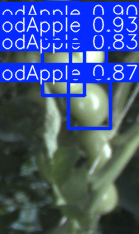

Ultralytics 8.3.239 🚀 Python-3.11.14 torch-2.9.1 CPU (AMD EPYC 7R32)

PyTorch: starting from '/home/warredv/Thesis_WDV/Yolo/runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)

ONNX: starting export with onnx 1.20.0 opset 22...


/home/warredv/miniconda3/envs/main-env/lib/python3.11/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.80...
ONNX: export success ✅ 1.2s, saved as '/home/warredv/Thesis_WDV/Yolo/runs/detect/train2/weights/best.onnx' (10.1 MB)

Export complete (1.4s)
Results saved to /home/warredv/Thesis_WDV/Yolo/runs/detect/train2/weights
Predict:         yolo predict task=detect model=/home/warredv/Thesis_WDV/Yolo/runs/detect/train2/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/home/warredv/Thesis_WDV/Yolo/runs/detect/train2/weights/best.onnx imgsz=640 data=../Data/apples/yolo_splits/inst500/dataset.yaml  
Visualize:       https://netron.app


In [ ]:
# Load a model
model = YOLO("yolo11n.pt")

# Train the model
train_results = model.train(
    data="../Data/apples/yolo_splits/inst500/dataset.yaml",  # path to dataset YAML
    epochs=100,  # number of training epochs
    imgsz=640,  # training image size
    device="cuda",  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu
)

# Evaluate model performance on the validation set
metrics = model.val()

# Perform object detection on an image
results = model("../Data/apples/images/test/IMG_0298.png")
results[0].show()

# Export the model to ONNX format
path = model.export(format="onnx")  # return path to exported model


image 1/1 /home/warredv/Thesis_WDV/Yolo/../Data/apples/images/test/IMG_0298.png: 544x640 12 GoodApples, 8 BadApples, 71.1ms
Speed: 2.2ms preprocess, 71.1ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)


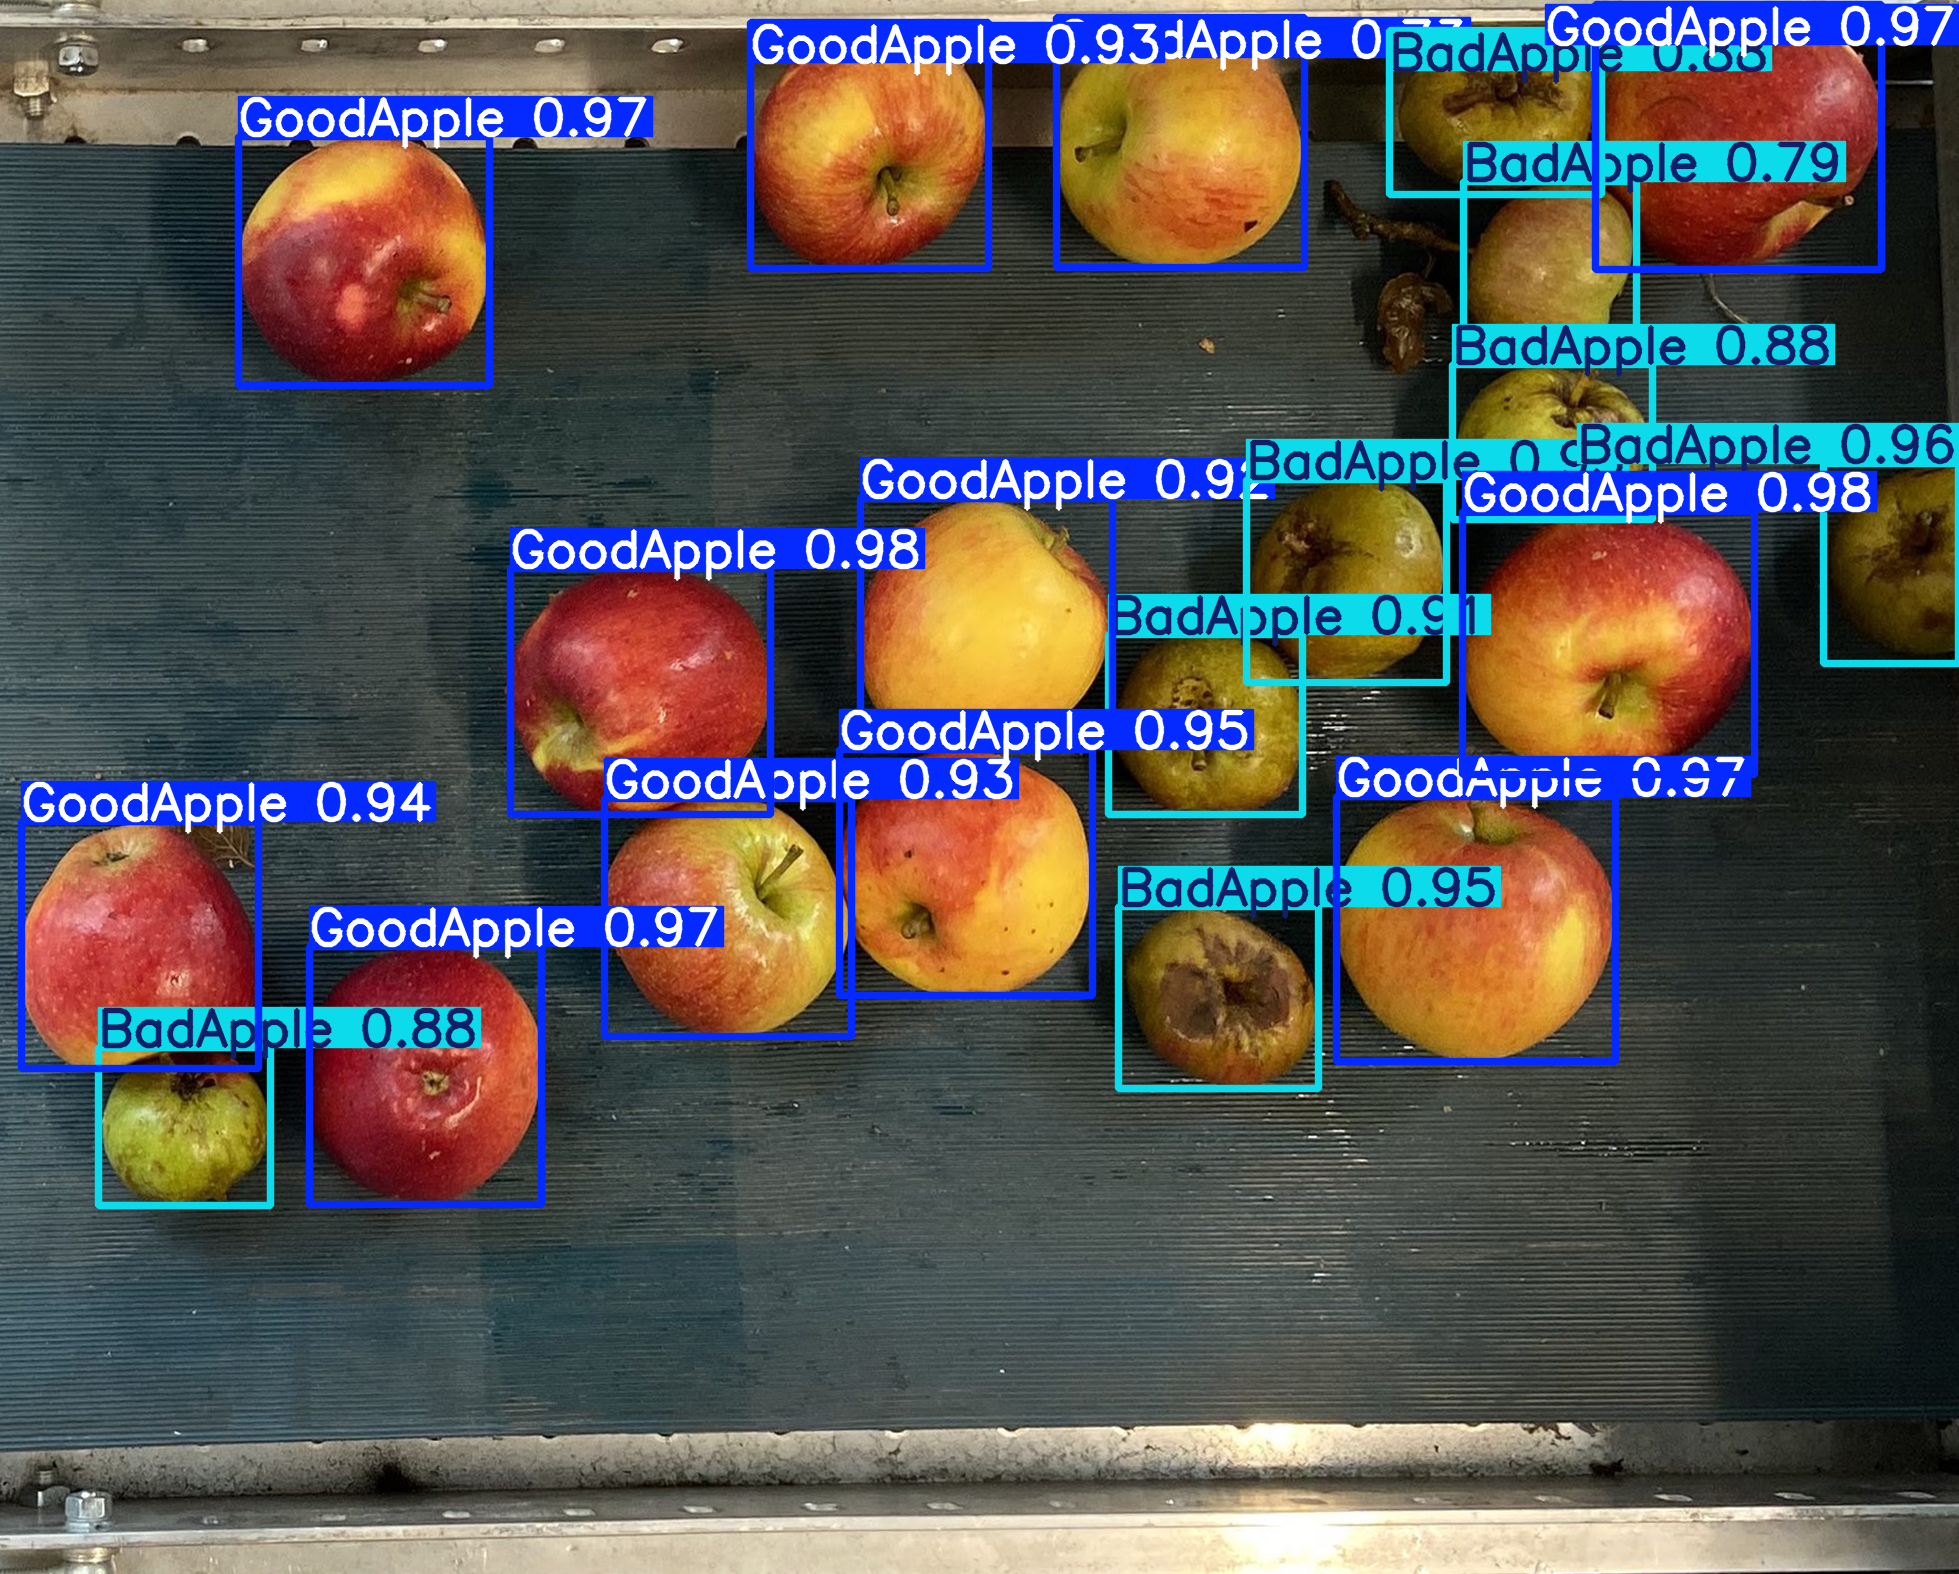

In [6]:

# Perform object detection on an image
results = model("../Data/apples/images/test/IMG_0298.png")
results[0].show()